# Point-estimate stress test — is the *mean* the right summary of a player's level?

**We rank players by their season *average* points. Is the mean the best point estimate, or does a robust / recency / upside statistic rank next-GW points better — within position?**

_Read-only pre-Phase-1 experiment ([docs/predictive-layer-plan.md](../../docs/predictive-layer-plan.md)). Decides what Phase-1 shrinkage should shrink toward._
Population & metrics inherited from Phase 0: `minutes > 0`, DGW excluded, GW > 3, leakage-checked, **within-position ranking only**.

> **How to read.** Each estimator summarizes a player's **strictly-prior** points (leakage-safe expanding stat). The mean is theory-optimal for *accumulation* but high-variance on a haul-driven target — so we test robust centers (median, trimmed, Huber), a recency-weighted mean (EW), and upside quantiles (p75/p90) as *rankers*. Headline is within-position Spearman; precision@k / NDCG@k are decision shortlists.

> **Conditional on appearance** (as Phase 0): metrics cover players who actually featured.

## Setup
> Build the candidate level columns and score each per position on the Phase-0 harness. Numbers come from `model.eval.level_estimators`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from dal.pipeline import load as load_mart, run as run_pipeline
from dal.exceptions import MartNotBuiltError, MartSchemaError
from model.eval.level_estimators import score_levels_by_position, LEVEL_ESTIMATORS
from model.eval.walkforward import POSITIONS

try:
    loaded = load_mart()
except (MartNotBuiltError, MartSchemaError) as err:
    print(f'Rebuilding mart ({type(err).__name__})...'); run_pipeline(force=True); loaded = load_mart()
res = score_levels_by_position(loaded.mart)
print(f'Study range: GW 1 - {loaded.data_cutoff_gw} | minutes > 0 | DGW excluded | within-position ranking')

Study range: GW 1 - 38 | minutes > 0 | DGW excluded | within-position ranking


## Per-position ranking — which point estimate ranks best?
> Read per position. The **incumbent mean** is highlighted; the dashed line is the best estimator for that position. Robust centers (median/trimmed/Huber) are expected to *tie* the mean (hauls are real signal, not noise to trim); the **EW mean** tests whether recency helps; **quantiles** test upside for captaincy.

spearman  precision_at_k  ndcg_at_k   k  n_gw
position estimator                                                        
GK       EW mean (hl=5)        0.0764          0.3257     0.4510   5    35
         Huber M-estimator     0.0431          0.3486     0.4638   5    35
         mean (incumbent)      0.0408          0.3600     0.4602   5    35
         trimmed mean (10%)    0.0351          0.3486     0.4508   5    35
         p90 (ceiling)         0.0344          0.3257     0.4625   5    35
         median                0.0206          0.3486     0.4737   5    35
         p75 (upside)          0.0202          0.3657     0.4711   5    35
DEF      median                0.1885          0.3314     0.4167  20    35
         Huber M-estimator     0.1869          0.3300     0.4191  20    35
         trimmed mean (10%)    0.1867          0.3314     0.4252  20    35
         mean (incumbent)      0.1853          0.3414     0.4263  20    35
         EW mean (hl=5)        0.1803          0.3271     0.4140  20    35
         p75 (upside)          0.1729          0.3186     0.4120  20    35
         p90 (ceiling)         0.1676          0.3129     0.4016  20    35
MID      EW mean (hl=5)        0.3406          0.2757     0.4347  20    35
         mean (incumbent)      0.3359          0.2829     0.4350  20    35
         trimmed mean (10%)    0.3356          0.2857     0.4343  20    35
         Huber M-estimator     0.3353          0.2857     0.4365  20    35
         median                0.3236          0.2800     0.4261  20    35
         p75 (upside)          0.3229          0.2857     0.4308  20    35
         p90 (ceiling)         0.2950          0.2743     0.4174  20    35
FWD      EW mean (hl=5)        0.3707          0.5111     0.5257   9    35
         mean (incumbent)      0.3490          0.4921     0.5106   9    35
         p75 (upside)          0.3350          0.4921     0.5137   9    35
         p90 (ceiling)         0.3335          0.5111     0.5186   9    35
         trimmed mean (10%)    0.3308          0.4857     0.5062   9    35
         Huber M-estimator     0.3147          0.4762     0.4921   9    35
         median                0.3009          0.4254     0.4630   9    35

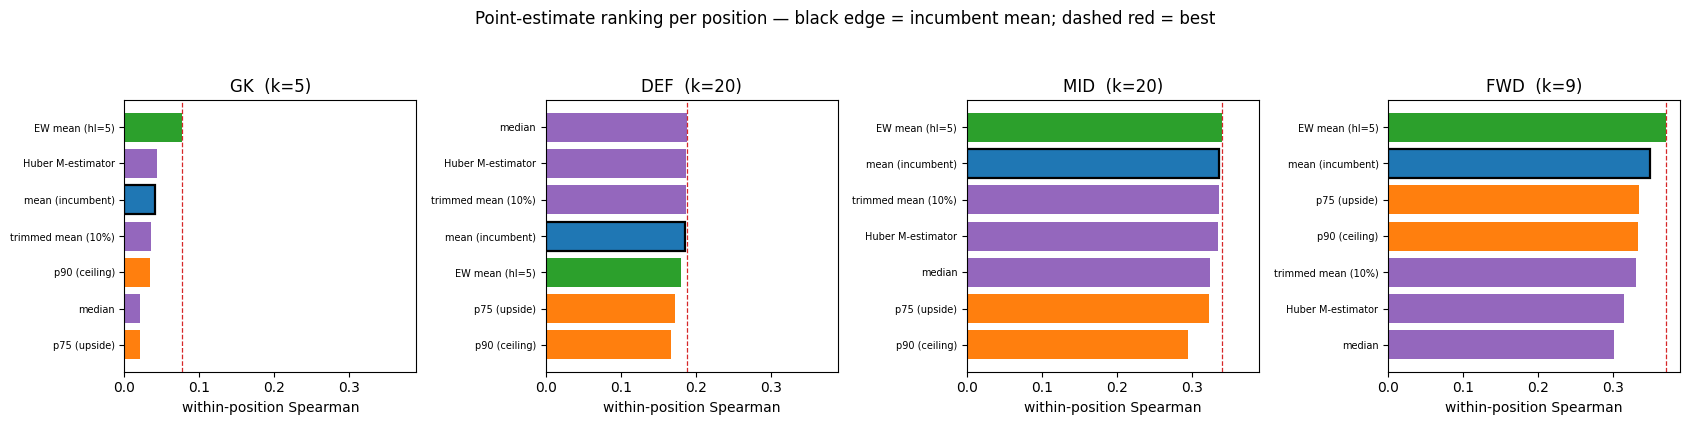

In [2]:
display(res.round(4))

colour = {lab: ('#1f77b4' if lab=='mean (incumbent)' else '#2ca02c' if 'EW' in lab else '#ff7f0e' if ('p75' in lab or 'p90' in lab) else '#9467bd') for lab in LEVEL_ESTIMATORS.values()}
fig, axes = plt.subplots(1, 4, figsize=(17, 4.0), sharex=True)
for ax, pos in zip(axes, POSITIONS):
    sub = res.xs(pos, level='position').sort_values('spearman')
    labels = sub.index
    bars = ax.barh(np.arange(len(labels)), sub['spearman'].fillna(0.0), color=[colour[l] for l in labels])
    for i, l in enumerate(labels):
        if l == 'mean (incumbent)':
            bars[i].set_edgecolor('black'); bars[i].set_linewidth(1.6)
    best = sub['spearman'].max(); ax.axvline(best, color='#d62728', ls='--', lw=0.9)
    ax.set_yticks(np.arange(len(labels))); ax.set_yticklabels(labels, fontsize=7)
    ax.set_title(f'{pos}  (k={int(sub["k"].iloc[0])})'); ax.axvline(0, color='k', lw=0.5)
    ax.set_xlabel('within-position Spearman')
fig.suptitle('Point-estimate ranking per position — black edge = incumbent mean; dashed red = best', y=1.05)
plt.tight_layout(); plt.show()

## Summary — what should Phase 1 shrink toward?

- **Robustification does not help.** Median / trimmed / Huber essentially *tie* the mean for DEF & MID (differences ~0.003, within noise) — confirming hauls are **real signal**, not noise to trim. For FWD, robust centers are *worse* (median worst) because they discard forward upside.
- **The one real edge is recency, concentrated in FWD.** The **EW mean** beats the plain mean in MID and especially **FWD (+~0.02)** — echoing Phase 0's rolling-5-wins-for-FWD. Recency carries a little signal for attackers; not for DEF (level-driven).
- **Quantiles are a different decision.** p75/p90 don't rank the body better, but p90 precision is competitive for FWD — relevant to *captaincy upside*, not general ranking.
- **GK** is near chance for every estimator — nothing to choose.

**Decision for Phase 1:** shrink toward the **mean** — no robust center beats it meaningfully, so the value is in *variance reduction (shrinkage)*, not robustification. Consider a **position-specific recency tilt for FWD** as a later refinement. Frozen numbers: [docs/studies/results/predictive-level-estimators.md](../../docs/studies/results/predictive-level-estimators.md).